In [20]:
# financial_sentiment_pipeline.py
import numpy as np
import pytesseract
from PIL import Image
import requests
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import pandas as pd
import json
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
from dotenv import load_dotenv
from google import genai

In [9]:
# ============================================================================
# STEP 1: OCR + LLM PROCESSING
# ============================================================================

def ocr_image(image_path):
    """Extract text from image"""
    image = Image.open(image_path)
    text = pytesseract.image_to_string(image)
    return text.strip()


def llm_process(text, system_prompt, api_token):
    """Pass text through LLM"""
    url = "https://router.huggingface.co/v1/chat/completions"
    
    payload = {
        "model": "meta-llama/Llama-3.1-8B-Instruct",
        "messages": [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ],
        "max_tokens": 2000,
        "temperature": 0.1
    }
    
    headers = {
        "Authorization": f"Bearer {api_token}",
        "Content-Type": "application/json"
    }
    
    response = requests.post(url, headers=headers, json=payload)
    result = response.json()
    
    return result["choices"][0]["message"]["content"]


def process_user_image(image_path, api_token):
    """Process user uploaded image through OCR + LLM pipeline"""
    print("Processing user image...")
    
    # OCR
    ocr_text = ocr_image(image_path)
    print(f"OCR extracted {len(ocr_text)} characters")
    
    # LLM cleaning and structuring
    system_prompt = """You are a text processing assistant. Your task is to:
1. Clean and correct any OCR errors in the provided text
2. Split the text into individual sentences
3. Return a JSON object with this structure: {"sentences": ["sentence1", "sentence2", ...]}

Only return valid JSON, no additional text or explanation."""
    
    llm_output = llm_process(ocr_text, system_prompt, api_token)
    
    # Parse JSON to DataFrame
    sentences_json = json.loads(llm_output)
    df = pd.DataFrame(sentences_json['sentences'], columns=['sentence'])
    
    print(f"Extracted {len(df)} sentences from image")
    return df

In [18]:

# ============================================================================
# STEP 2: LOAD DATASET
# ============================================================================

def load_financial_data():
    """Load Financial PhraseBank dataset"""
    print("Loading Financial PhraseBank dataset...")
    
    # Use alternative dataset that's properly formatted
    dataset = load_dataset('FinanceInc/auditor_sentiment', split='train')
    
    # Convert to DataFrame
    df = pd.DataFrame(dataset)
    
    # This dataset uses 'sentence' and 'label' columns
    # Map labels if needed: check what labels are in the dataset
    print(f"Loaded {len(df)} sentences")
    print(f"Columns: {df.columns.tolist()}")
    print(f"Sample labels: {df['label'].unique()}")
    
    # Map to standard format
    if df['label'].dtype == 'object':
        # If labels are already strings
        df['label_name'] = df['label']
    else:
        # If labels are numeric
        label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}
        df['label_name'] = df['label'].map(label_map)
    
    print(f"Label distribution: {df['label_name'].value_counts().to_dict()}")
    
    return df

In [11]:
# ============================================================================
# STEP 3: LOAD MODEL AND RUN INFERENCE
# ============================================================================

def load_finbert_model():
    """Load FinBERT model and tokenizer"""
    print("Loading FinBERT model...")
    model_name = "ProsusAI/finbert"
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertForSequenceClassification.from_pretrained(model_name)
    model.eval()
    return tokenizer, model


def predict_sentiment(texts, tokenizer, model):
    """Run FinBERT inference on list of texts"""
    print(f"Running inference on {len(texts)} samples...")
    
    results = []
    label_names = ['positive', 'negative', 'neutral']
    
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        
        with torch.no_grad():
            outputs = model(**inputs)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
        
        pred_label_idx = torch.argmax(probs).item()
        pred_label = label_names[pred_label_idx]
        confidence = probs[0][pred_label_idx].item()
        
        results.append({
            'predicted_label': pred_label,
            'confidence': confidence,
            'prob_positive': probs[0][0].item(),
            'prob_negative': probs[0][1].item(),
            'prob_neutral': probs[0][2].item()
        })
    
    return pd.DataFrame(results)

In [12]:
# ============================================================================
# STEP 4: EXPLAINABILITY WITH LIME
# ============================================================================

def setup_lime_explainer(tokenizer, model):
    """Create LIME explainer for FinBERT"""
    label_names = ['positive', 'negative', 'neutral']
    
    def predictor_fn(texts):
        """Wrapper function for LIME to call FinBERT"""
        predictions = []
        for text in texts:
            inputs = tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
            with torch.no_grad():
                outputs = model(**inputs)
                probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
            predictions.append(probs[0].numpy())
        return np.array(predictions)
    
    explainer = LimeTextExplainer(class_names=label_names)
    return explainer, predictor_fn


def explain_predictions(df, sentences, tokenizer, model, num_samples=5):
    """Generate LIME explanations for sample predictions"""
    print(f"Generating LIME explanations for {num_samples} samples...")
    
    explainer, predictor_fn = setup_lime_explainer(tokenizer, model)
    explanations = []
    
    # Get diverse samples (one from each sentiment if possible)
    sample_indices = []
    for label in df['predicted_label'].unique():
        label_indices = df[df['predicted_label'] == label].index.tolist()
        if label_indices:
            sample_indices.append(label_indices[0])
    
    # Fill remaining samples randomly
    remaining = num_samples - len(sample_indices)
    if remaining > 0:
        other_indices = [i for i in range(len(df)) if i not in sample_indices]
        sample_indices.extend(other_indices[:remaining])
    
    for idx in sample_indices[:num_samples]:
        text = sentences[idx]
        predicted_label = df.loc[idx, 'predicted_label']
        
        exp = explainer.explain_instance(
            text, 
            predictor_fn, 
            num_features=10,
            num_samples=500
        )
        
        # Get word contributions
        word_weights = exp.as_list()
        
        explanations.append({
            'index': idx,
            'sentence': text,
            'predicted_label': predicted_label,
            'word_contributions': word_weights,
            'lime_object': exp
        })
    
    return explanations

In [13]:
# ============================================================================
# STEP 5: ANALYSIS AND VISUALIZATION
# ============================================================================

def analyze_results(df, has_ground_truth=False):
    """Generate summary statistics and interesting findings"""
    print("Analyzing results...")
    
    analysis = {
        'total_samples': len(df),
        'sentiment_distribution': df['predicted_label'].value_counts().to_dict(),
        'avg_confidence': df['confidence'].mean(),
        'high_confidence_samples': len(df[df['confidence'] > 0.9]),
        'low_confidence_samples': len(df[df['confidence'] < 0.6])
    }
    
    # Most confident predictions per class
    most_confident = {}
    for label in df['predicted_label'].unique():
        label_df = df[df['predicted_label'] == label]
        most_confident[label] = label_df.nlargest(3, 'confidence').index.tolist()
    
    analysis['most_confident_per_class'] = most_confident
    
    # Least confident (most uncertain predictions)
    analysis['most_uncertain'] = df.nsmallest(5, 'confidence').index.tolist()
    
    # Calculate accuracy if ground truth available
    if has_ground_truth and 'label_name' in df.columns:
        accuracy = (df['predicted_label'] == df['label_name']).mean()
        analysis['accuracy'] = accuracy
        
        # Confusion matrix data
        confusion_data = pd.crosstab(df['label_name'], df['predicted_label'])
        analysis['confusion_matrix'] = confusion_data
    
    return analysis


def create_visualizations(df, analysis, has_ground_truth=False):
    """Create plots and charts"""
    print("Creating visualizations...")
    
    # Sentiment distribution
    fig1, ax1 = plt.subplots(figsize=(8, 6))
    sentiment_counts = df['predicted_label'].value_counts()
    sentiment_counts.plot(kind='bar', ax=ax1, color=['green', 'red', 'gray'])
    ax1.set_title('Sentiment Distribution', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Sentiment')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.savefig('sentiment_distribution.png', dpi=300)
    print("Saved: sentiment_distribution.png")
    
    # Confidence distribution
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    ax2.hist(df['confidence'], bins=30, color='skyblue', edgecolor='black')
    ax2.set_title('Prediction Confidence Distribution', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Confidence Score')
    ax2.set_ylabel('Frequency')
    plt.tight_layout()
    plt.savefig('confidence_distribution.png', dpi=300)
    print("Saved: confidence_distribution.png")
    
    # Confusion matrix if ground truth available
    if has_ground_truth and 'confusion_matrix' in analysis:
        fig3, ax3 = plt.subplots(figsize=(8, 6))
        sns.heatmap(analysis['confusion_matrix'], annot=True, fmt='d', cmap='Blues', ax=ax3)
        ax3.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
        ax3.set_ylabel('True Label')
        ax3.set_xlabel('Predicted Label')
        plt.tight_layout()
        plt.savefig('confusion_matrix.png', dpi=300)
        print("Saved: confusion_matrix.png")


def gemini_analysis(analysis, df, api_key):
    """Optional: Use Gemini to generate insights"""
    print("Generating Gemini insights...")
    
    client = genai.Client(api_key=api_key)
    MODEL_TO_USE = "gemini-1.5-flash"
    
    # Prepare summary for Gemini
    summary_text = f"""
I have analyzed {analysis['total_samples']} financial sentences using FinBERT sentiment analysis.

Results:
- Sentiment Distribution: {analysis['sentiment_distribution']}
- Average Confidence: {analysis['avg_confidence']:.2%}
- High Confidence Predictions (>90%): {analysis['high_confidence_samples']}
- Low Confidence Predictions (<60%): {analysis['low_confidence_samples']}

Based on these aggregate statistics, provide 3-4 brief insights about the sentiment patterns in financial text. 
Focus on what the confidence levels and distribution might indicate about financial discourse.
Keep it concise and actionable.
"""
    
    response = client.models.generate_content(
        model=MODEL_TO_USE,
        contents=summary_text
    )
    
    return response.text


# ============================================================================
# MAIN PIPELINE
# ============================================================================

def run_pipeline(use_dataset=True, image_path=None, api_token=None, gemini_api_key=None):
    """Run complete pipeline"""
    
    # Load model
    tokenizer, model = load_finbert_model()
    
    # Get data
    if use_dataset:
        df = load_financial_data()
        sentences = df['sentence'].tolist()
        has_ground_truth = True
    else:
        df = process_user_image(image_path, api_token)
        sentences = df['sentence'].tolist()
        has_ground_truth = False
    
    # Run predictions
    predictions_df = predict_sentiment(sentences, tokenizer, model)
    df = pd.concat([df.reset_index(drop=True), predictions_df], axis=1)
    
    # Save predictions
    df.to_csv('predictions.csv', index=False)
    print("Saved: predictions.csv")
    
    # LIME explanations
    import numpy as np
    explanations = explain_predictions(df, sentences, tokenizer, model, num_samples=5)
    
    # Save explanations
    exp_summary = []
    for exp in explanations:
        exp_summary.append({
            'index': exp['index'],
            'sentence': exp['sentence'],
            'predicted_label': exp['predicted_label'],
            'top_words': exp['word_contributions'][:5]
        })
    
    with open('explanations.json', 'w') as f:
        json.dump(exp_summary, f, indent=2)
    print("Saved: explanations.json")
    
    # Analysis
    analysis = analyze_results(df, has_ground_truth)
    
    # Visualizations
    create_visualizations(df, analysis, has_ground_truth)
    
    # Print summary
    print("\n" + "="*60)
    print("PIPELINE RESULTS SUMMARY")
    print("="*60)
    print(f"Total Samples: {analysis['total_samples']}")
    print(f"Sentiment Distribution: {analysis['sentiment_distribution']}")
    print(f"Average Confidence: {analysis['avg_confidence']:.2%}")
    
    if has_ground_truth and 'accuracy' in analysis:
        print(f"Accuracy: {analysis['accuracy']:.2%}")
    
    print(f"\nMost Uncertain Predictions (indices): {analysis['most_uncertain']}")
    
    print("\n" + "="*60)
    print("SAMPLE LIME EXPLANATIONS")
    print("="*60)
    for exp in explanations[:3]:
        print(f"\nSentence: {exp['sentence'][:100]}...")
        print(f"Predicted: {exp['predicted_label']}")
        print(f"Top Contributing Words:")
        for word, weight in exp['word_contributions'][:5]:
            print(f"  - '{word}': {weight:+.3f}")
    
    # Optional Gemini insights
    if gemini_api_key:
        gemini_insights = gemini_analysis(analysis, df, gemini_api_key)
        print("\n" + "="*60)
        print("GEMINI AI INSIGHTS")
        print("="*60)
        print(gemini_insights)
        
        with open('gemini_insights.txt', 'w') as f:
            f.write(gemini_insights)
        print("Saved: gemini_insights.txt")
    
    return df, explanations, analysis

Loading FinBERT model...
Loading Financial PhraseBank dataset...
Loaded 3877 sentences
Columns: ['sentence', 'label']
Sample labels: [2 1 0]
Label distribution: {'neutral': 2320, 'positive': 1077, 'negative': 480}
Running inference on 3877 samples...
Saved: predictions.csv
Generating LIME explanations for 5 samples...
Saved: explanations.json
Analyzing results...
Creating visualizations...
Saved: sentiment_distribution.png
Saved: confidence_distribution.png
Saved: confusion_matrix.png

PIPELINE RESULTS SUMMARY
Total Samples: 3877
Sentiment Distribution: {'neutral': 2066, 'positive': 1229, 'negative': 582}
Average Confidence: 87.45%
Accuracy: 88.88%

Most Uncertain Predictions (indices): [3395, 2506, 2182, 313, 3823]

SAMPLE LIME EXPLANATIONS

Sentence: Altia 's operating profit jumped to EUR 47 million from EUR 6.6 million ....
Predicted: positive
Top Contributing Words:
  - 'jumped': -0.041
  - 'to': -0.031
  - 'EUR': -0.027
  - 'from': +0.024
  - '6': +0.017

Sentence: Vaisala , head

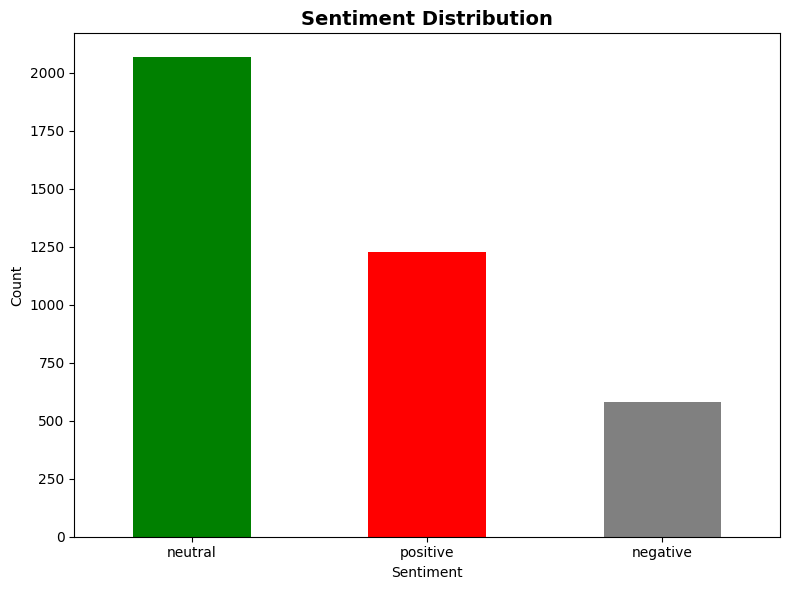

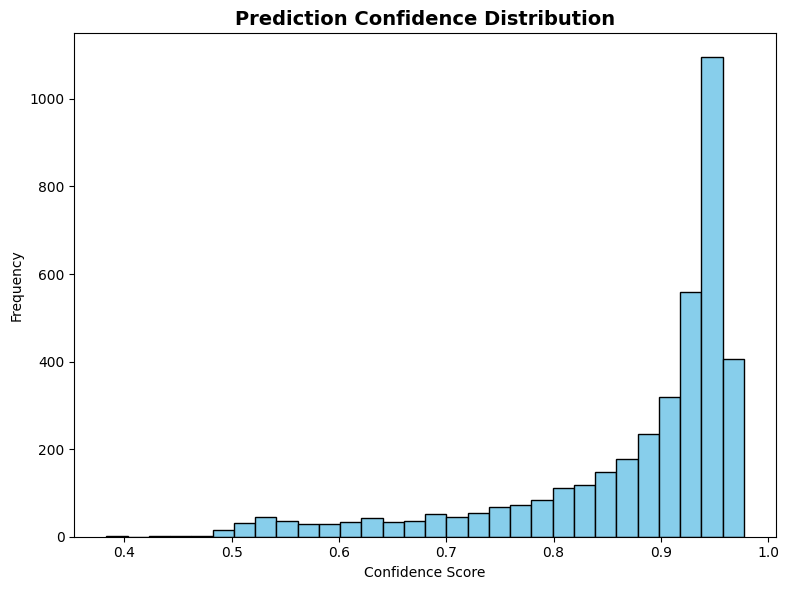

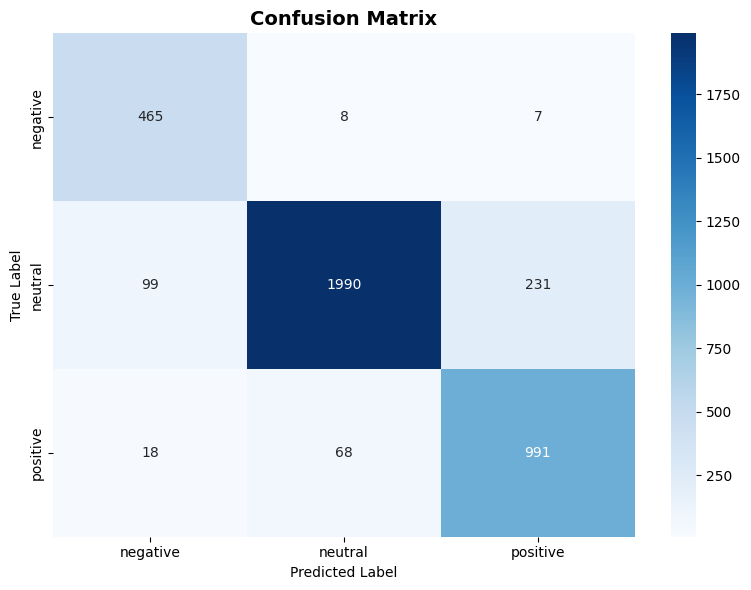

In [21]:
# ============================================================================
# EXECUTION
# ============================================================================

if __name__ == "__main__":
    # Configuration
    USE_DATASET = True  # Set to False to use image upload
    IMAGE_PATH = None  # Set path if USE_DATASET = False
    
    # Load API keys from environment
    load_dotenv()
    LLAMA_API_TOKEN = os.getenv("HUGGINGFACE_API_TOKEN")
    GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
    
    # Run pipeline
    df, explanations, analysis = run_pipeline(
        use_dataset=USE_DATASET,
        image_path=IMAGE_PATH,
        api_token=LLAMA_API_TOKEN,
        gemini_api_key=GEMINI_API_KEY
    )
    
    print("\nPipeline complete! Generated files:")
    print("- predictions.csv")
    print("- explanations.json")
    print("- sentiment_distribution.png")
    print("- confidence_distribution.png")
    if 'label_name' in df.columns:
        print("- confusion_matrix.png")
    if GEMINI_API_KEY:
        print("- gemini_insights.txt")